In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from skimage.measure import shannon_entropy
from skimage import data, feature, color
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.metrics import structural_similarity as ssim
from skimage.draw import circle_perimeter
import xraylib as xl
import numpy as np
from sklearn.metrics import mutual_info_score
from skimage import exposure
import scipy.constants
from scipy.ndimage import shift
import PIL

In [35]:
n_samples_bootstrap = 1000
num_patches = 25

In [36]:
def detect_center(image):
    # Detect edges (Canny)
    edges = feature.canny(image, sigma=2)

    #Perform Hough Transform for circles
    radii = np.arange(30, 50, 1)  # search radii range
    hough_res = hough_circle(edges, radii)

    # Identify the most prominent circle
    accums, cx, cy, radii = hough_circle_peaks(hough_res, radii,
                                           total_num_peaks=1)
    
    return cx[0], cy[0], radii[0]

In [39]:
def detect_border(image_polar):
    pos_border = []
    for row in range(image_polar.shape[0]):
        row_profile = np.abs(image_polar[row, :])
        max_row_profile = np.argmax(row_profile)
        pos_border.append([row, max_row_profile])
    pos_border = np.array(pos_border)
    return pos_border

In [40]:
def binning(profile, bin_size=5):
    """Bin the profile by averaging over bin_size."""
    n_bins = len(profile) // bin_size
    binned = profile[:n_bins * bin_size].reshape(n_bins, bin_size).mean(axis=1)
    return binned

In [65]:
def SNR(img, img_polar, img_border=None, img_polar_border=None):
    pos_border = []
    if(img_border is None and img_polar_border is None):
        for row in range(img_polar.shape[0]):
            row_profile = np.abs(img_polar[row, :])
            max_row_profile = np.argmax(row_profile)
            pos_border.append([row, max_row_profile])
        pos_border = np.array(pos_border)
    else:
        for row in range(img_polar_border.shape[0]):
            row_profile = np.abs(img_polar_border[row, :])
            max_row_profile = np.argmax(row_profile)
            pos_border.append([row, max_row_profile])
        pos_border = np.array(pos_border)

    profile = binning(img_polar[pos_border[:,0], pos_border[:,1]], bin_size=1)
    lower, upper = np.percentile(profile, [5, 95])  # keep between 5th and 95th percentile
    profile = profile[(profile > lower) & (profile < upper)]
    S_plus = np.max(profile)
    S_minus = np.min(profile)
    #S_plus = np.percentile(profile, 95)
    #S_minus = np.percentile(profile, 5)
    std_bkg = np.std(img[0:50, 0:50])

    SNR = (S_plus - S_minus) / std_bkg
    return SNR

In [69]:
def SNR(img, img_polar, img_border=None, img_polar_border=None):
    pos_border = []
    if(img_border is None and img_polar_border is None):
        for row in range(img_polar.shape[0]):
            row_profile = np.abs(img_polar[row, :])
            max_row_profile = np.argmax(row_profile)
            pos_border.append([row, max_row_profile])
        pos_border = np.array(pos_border)
    else:
        for row in range(img_polar_border.shape[0]):
            row_profile = np.abs(img_polar_border[row, :])
            max_row_profile = np.argmax(row_profile)
            pos_border.append([row, max_row_profile])
        pos_border = np.array(pos_border)

    profile = binning(img_polar[pos_border[:,0], pos_border[:,1]], bin_size=1)
    lower, upper = np.percentile(profile, [5, 90])  # keep between 5th and 95th percentile
    profile = profile[(profile > lower) & (profile < upper)]
    
    # --- Mejora: Máximo y Mínimo promedio (Top 20 píxeles) ---
    n_pixels = 20
    # Ordenamos el perfil de menor a mayor
    sorted_profile = np.sort(profile)
    
    if len(sorted_profile) >= n_pixels:
        # Promedio de los 20 valores más bajos
        S_minus = np.mean(sorted_profile[:n_pixels])
        # Promedio de los 20 valores más altos
        S_plus = np.mean(sorted_profile[-n_pixels:])
    else:
        # Caso de seguridad si el perfil filtrado es muy pequeño
        S_plus = np.max(profile)
        S_minus = np.min(profile)
        
    std_bkg = np.std(img[0:50, 0:50])

    SNR = (S_plus - S_minus) / std_bkg
    return SNR

In [42]:
def bootstrap_SNR(img, img_polar, n_bootstrap=n_samples_bootstrap, random_state=None, img_border=None, img_polar_border=None, outlier_removal=False):

    if(outlier_removal):
        low, high = np.percentile(img, [2.5, 97.5])
        img[(img < low) | (img > high)] = np.mean(img)
        low_polar, high_polar = np.percentile(img_polar, [1, 99])
        img_polar[(img_polar < low_polar) | (img_polar > high_polar)] = np.mean(img_polar)

    rng = np.random.default_rng(random_state)

    snr0 = SNR(img, img_polar, img_border=img_border, img_polar_border=img_polar_border)  # original SNR
    snr_values = []

    n_rows, n_cols = img_polar.shape

    for _ in range(n_bootstrap):
        # Resample rows of img_polar with replacement
        resampled_rows = rng.choice(n_rows, size=n_rows, replace=True)
        img_polar_resampled = img_polar[resampled_rows, :]
        if(img_border is not None and img_polar_border is not None):
            img_polar_resampled_border = img_polar_border[resampled_rows, :]

        # Resample background pixels as well
        bkg = img[0:50, 0:50].ravel()
        bkg_resampled = rng.choice(bkg, size=bkg.shape[0], replace=True)
        img_resampled = img.copy()
        img_resampled[0:50, 0:50] = bkg_resampled.reshape(50, 50)

        if(img_border is not None and img_polar_border is not None):
            bkg_border = img_border[0:50, 0:50].ravel()
            bkg_resampled_border = rng.choice(bkg_border, size=bkg_border.shape[0], replace=True)
            img_resampled_border = img_border.copy()
            img_resampled_border[0:50, 0:50] = bkg_resampled_border.reshape(50, 50)

            # Call your original function directly
            snr_values.append(SNR(img_resampled, img_polar_resampled, img_border=img_resampled_border, img_polar_border=img_polar_resampled_border))

        else:
            snr_values.append(SNR(img_resampled, img_polar_resampled))

    snr_values = np.array(snr_values)
    snr_mean = np.mean(snr_values)
    snr_std = np.std(snr_values)
    snr_ci = np.percentile(snr_values, [2.5, 97.5])  # 95% CI

    return snr_mean, snr_std

In [43]:
def NRMSE(profile_ref, profile_test):
    """Compute the Root Mean Square Error between two images."""

    max, min = np.max(profile_ref), np.min(profile_ref)
    return 100*np.sqrt(np.mean((profile_ref - profile_test) ** 2))/(max - min)

In [44]:
def bootstrap_NRMSE(profile_ref, profile_test, n_boot=n_samples_bootstrap, outlier_removal=False):
    """Compute NRMSE and its bootstrap uncertainty."""

    if(outlier_removal):
        low, high = np.percentile(profile_test, [1, 99])
        profile_ref[(profile_test < low) | (profile_test > high)] = np.mean(profile_test)

    rmse_values = []
    n_pixels = len(profile_ref)
    
    for _ in range(n_boot):
        # Sample pixel indices with replacement
        indices = np.random.choice(n_pixels, size=n_pixels, replace=True)
        
        # Compute MI on the resampled pixels
        rmse = NRMSE(profile_ref[indices], profile_test[indices])
        rmse_values.append(rmse)
    
    rmse_values = np.array(rmse_values)
    rmse_mean = rmse_values.mean()
    rmse_std = rmse_values.std()
    return rmse_mean, rmse_std

In [45]:
def Visibility(img):
    """Compute the visibility of an image."""
    I_mean = np.mean(img)
    I_std = np.std(img)
    visibility = 100*(I_std / I_mean)
    return visibility

In [46]:
def k_from_E(E):
    k =  2. * np.pi * (E * 1e3 * 1.6022e-19) / (scipy.constants.h * scipy.constants.c) # in 1/m
    return k

In [47]:
def create_sphere(N_pix, R, cx, cy):
                       
    #cx, cy = N_pix/2, N_pix/2               # sphere center (pixels)
    
    y, x = np.ogrid[:N_pix, :N_pix]
    r = np.hypot(x - cx, y - cy)
    
    # path length projection
    proj = np.zeros((N_pix, N_pix), float)
    inside = r <= R
    proj[inside] = 2.0 * np.sqrt(R**2 - r[inside]**2)
    
    # normalize for display
    proj /= proj.max()

    return proj

In [48]:
def ground_truth(cx, cy, R=38, N_pix=190):
    E = 16.0  # in keV
    k = k_from_E(E)

    mat = "C6H11NO"
    mat_density = 1.14
    n = xl.Refractive_Index(mat, E, mat_density)
    delta = 1 - n.real
    mu_mass = xl.CS_Total_CP(mat, E)
    mu_in_1_m = mu_mass*mat_density*1e2 

    t_map = create_sphere(N_pix=190, R=38, cx=cx, cy=cy)

    phase_theo = delta*k*t_map
    dy_theo, dx_theo = np.gradient(phase_theo)
    dy_theo = dy_theo/np.max(dy_theo)
    dx_theo = dx_theo/np.max(dx_theo)

    return dx_theo, dy_theo, phase_theo

In [49]:
def to_polar(img):
    """Convert Cartesian image to polar coordinates."""
    from skimage.transform import warp_polar
    return warp_polar(img, scaling="linear")

## 1. Focal Spot Study

In [50]:
folder_names = ["5um", "10um" ,"20um", "30um", "50um", "75um", "100um"]
focal_spots = [ 5, 10,20, 30, 50, 75, 100]  # in micrometers
input_folder = "/home/c.tibambre/FS_Study/Poli_Results_Umpa_SiC/"
dx_name = "dx.txt"
dy_name = "dy.txt"
dx_images = []
dy_images = []
dx_images_polar = []
dy_images_polar = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    print(dx.shape)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    dx = dx / np.max(np.abs(dx))  # Normalize to max value
    dy = dy / np.max(np.abs(dy))  # Normalize to max value
    dx_images_polar.append(to_polar(dx))
    dy_images_polar.append(to_polar(dy))
    dx_images.append(dx)
    dy_images.append(dy)



(190, 190)
(190, 190)
(190, 190)
(190, 190)
(190, 190)
(190, 190)
(190, 190)


In [51]:
# Find center and radius:

img1 = dx_images[0]
cx, cy, R = detect_center(img1)

print(cx, cy, R)

98 98 39


In [52]:
ground_truth_x = ground_truth(cx=cx, cy=cy,R=R)[0]#shift(ground_truth(cx=cx, cy=cy,R=R)[0], shift=(3, 1), mode='constant', cval=0.0)
ground_truth_y = ground_truth(cx=cx, cy=cy,R=R)[1]#shift(ground_truth(cx=cx, cy=cy,R=R)[1], shift=(3, 1), mode='constant', cval=0.0)
polar_ground_truth_x = to_polar(ground_truth_x)
polar_ground_truth_y = to_polar(ground_truth_y)

ground_truth_contour_x = detect_border(image_polar=polar_ground_truth_x)
ground_truth_contour_y = detect_border(image_polar=polar_ground_truth_y)

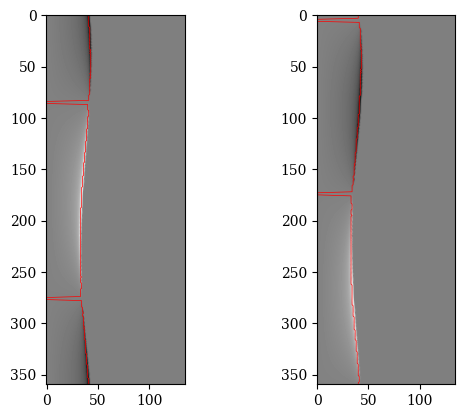

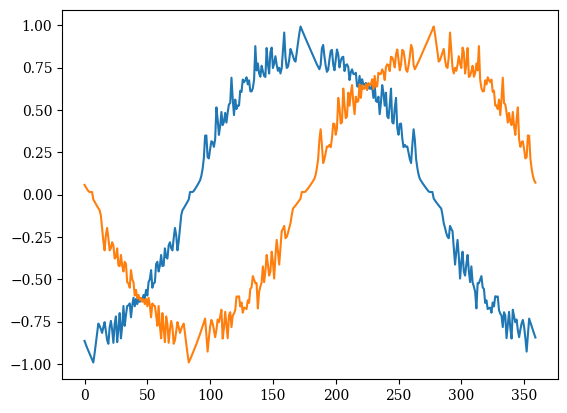

In [53]:
plt.figure()

plt.subplot(1,2,1)
plt.imshow(polar_ground_truth_x, cmap="gist_gray")
plt.plot(ground_truth_contour_x[:,1], ground_truth_contour_x[:,0], color='red', linewidth=0.5)

plt.subplot(1,2,2)
plt.imshow(polar_ground_truth_y, cmap="gist_gray")
plt.plot(ground_truth_contour_y[:,1], ground_truth_contour_y[:,0], color='red', linewidth=0.5)

plt.figure()
plt.plot(polar_ground_truth_x[ground_truth_contour_x[:,0], ground_truth_contour_x[:,1]], label="Contour X")
plt.plot(polar_ground_truth_y[ground_truth_contour_y[:,0], ground_truth_contour_y[:,1]], label="Contour Y")

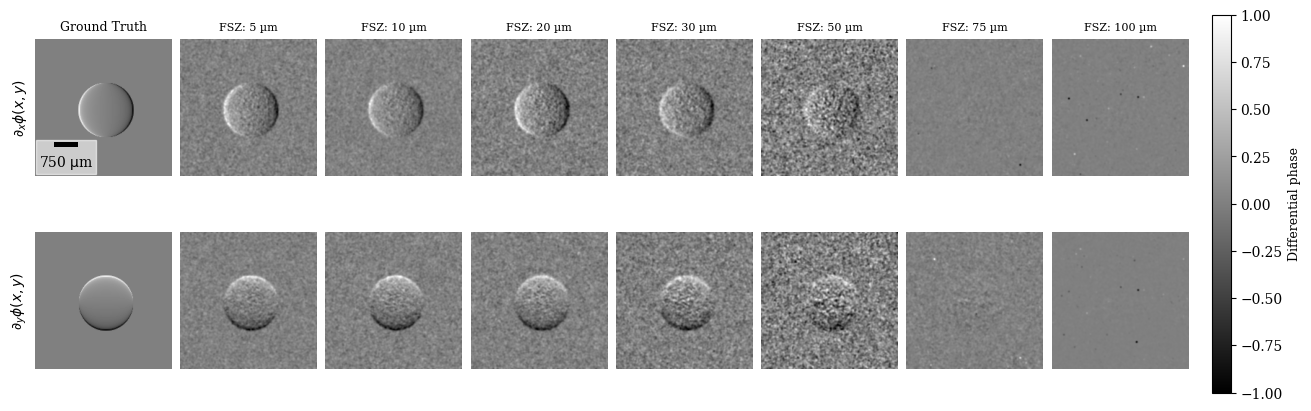

In [54]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
plt.rcParams['font.family']='serif'

# Increase columns by 1 to leave space at the beginning
n_cols = len(focal_spots) + 1

fig, axes = plt.subplots(
    2, n_cols,
    figsize=(13, 4),
    constrained_layout=True
)

# --- TOP ROW (dx images) ---
for i in range(len(focal_spots)):

    ax_dx = axes[0, i + 1]   # shift by 1
    im_dx = ax_dx.imshow(dx_images[i], cmap='gray', vmin=-1, vmax=1)

    ax_dx.set_title(f"FSZ: {focal_spots[i]} µm", fontsize=8)
    ax_dx.tick_params(left=False, bottom=False,
                      labelleft=False, labelbottom=False)

    for spine in ax_dx.spines.values():
        spine.set_visible(False)


# --- BOTTOM ROW (dy images) ---
for i in range(len(focal_spots)):

    ax_dy = axes[1, i + 1]   # shift by 1
    im_dy = ax_dy.imshow(dy_images[i], cmap='gray', vmin=-1, vmax=1)

    ax_dy.tick_params(left=False, bottom=False,
                      labelleft=False, labelbottom=False)

    for spine in ax_dy.spines.values():
        spine.set_visible(False)


# --- FIRST COLUMN (Ground Truth) ---
ax_0 = axes[0, 0]
im_0 = ax_0.imshow(ground_truth_x, cmap='gray', vmin=-1, vmax=1)

ax_0.set_title("Ground Truth", fontsize=9)
ax_0.set_ylabel(r'$\partial_x \phi(x,y)$', fontsize=10)

ax_0.tick_params(left=False, bottom=False,
                 labelleft=False, labelbottom=False)

for spine in ax_0.spines.values():
    spine.set_visible(False)

scalebar = ScaleBar(
    22.5, "um",
    color="black",
    location="lower left",
    box_alpha=0.6,
    scale_loc="bottom",
    width_fraction=0.03
)

ax_0.add_artist(scalebar)


ax_ncols = axes[1, 0]
im_ncols = ax_ncols.imshow(ground_truth_y, cmap='gray', vmin=-1, vmax=1)

ax_ncols.set_ylabel(r'$\partial_y \phi(x,y)$', fontsize=10)

ax_ncols.tick_params(left=False, bottom=False,
                     labelleft=False, labelbottom=False)

for spine in ax_ncols.spines.values():
    spine.set_visible(False)


# --- SINGLE SHARED COLORBAR ---
cbar = fig.colorbar(
    im_dx,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02
)

cbar.set_label("Differential phase", fontsize=9)


# --- SAVE ---
plt.savefig("DiffPhase_vs_FocalSpotSize.pdf",
            dpi=300,
            bbox_inches='tight')

plt.savefig("DiffPhase_vs_FocalSpotSize.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [55]:
def phaseint_fourier(dpc_row, dpc_col):
    """
    Implements fourier integration method for two differential quantities.

    Assumes 2 N-dimensional arrays which contain differential quantities
    in the LAST two dimensions (-2 & -1).
    Note that the input arrays are numerical derivatives (i.e., the
    difference of adjacent pixel values), not physical derivatives (d/dx).
    In other words, this function is equivalent to numerical integration,
    similar to `np.cumsum()`.

    Parameters
    ----------
    dpc_row : ndarray
        Partial derivative of image along second-to-last axis
        (i.e., axis 0 for a 2d input, "np.diff(img, 0)").
    dpc_col : ndarray
        Partial derivative of image along last axis
        (i.e., axis 1 for a 2d input, "np.diff(img, 1)").
        Must have same shape as `dpc_row`.
        
    Returns
    -------
    img : ndarray
        Integrated image, i.e., the array `img` for which
        `dpc_row = np.diff(img, 0)` and
        `dpc_col = np.diff(img, 1)` (except that the output of
        `np.diff()` is one pixel smaller than its input, whereas `img`
        has the same shape as `dpc_row` and `dpc_col`).
    """
    import numpy as np
    
    py = dpc_row
    px = dpc_col
    sh = px.shape
    sh = np.asarray(sh)
    fac = np.ones_like(sh)
    fac[-2:] = 2
    f = np.zeros(sh * fac, dtype=complex)
    f[..., :sh[-2], :sh[-1]] = -px[..., ::-1, ::-1] - 1j*py[..., ::-1, ::-1]
    f[..., :sh[-2], sh[-1]:] = -px[..., ::-1, :] + 1j*py[..., ::-1, :]
    f[..., sh[-2]:, :sh[-1]] = px[..., :, ::-1] - 1j*py[..., :, ::-1]
    f[..., sh[-2]:, sh[-1]:] = px + 1j*py
    qy = 2*np.pi*np.fft.fftfreq(f.shape[1]).reshape((1, -1)) # horizontal
    qx = 2*np.pi*np.fft.fftfreq(f.shape[0]).reshape((-1, 1)) # vertical
    qy[0,0] = qx[0,0] = 1e-9
    inv_qc = 1. / (1j*(qx + 1j*qy))
    inv_qc[..., 0, 0] = 0
    nf = np.fft.ifft2(np.fft.fft2(f) * inv_qc)

    return np.real(nf[..., sh[-2]:, sh[-1]:])

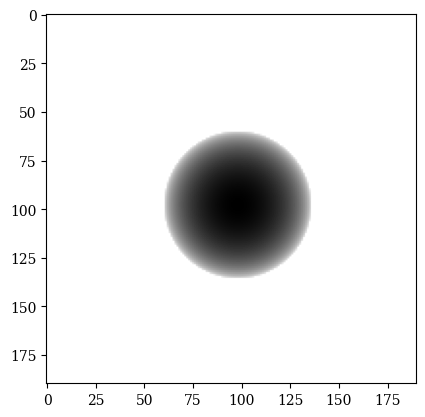

In [56]:
phase_theo = -ground_truth(cx=cx, cy=cy,R=R)[2]
plt.imshow(phase_theo, cmap="gist_gray")
#plt.colorbar()

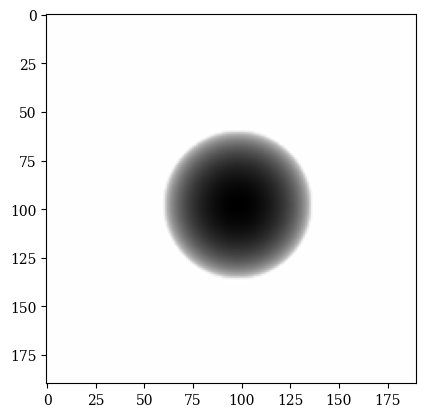

In [57]:

phi_UMPA = -phaseint_fourier(ground_truth_x, ground_truth_y)

plt.imshow(phi_UMPA, cmap='gray')
#plt.colorbar()

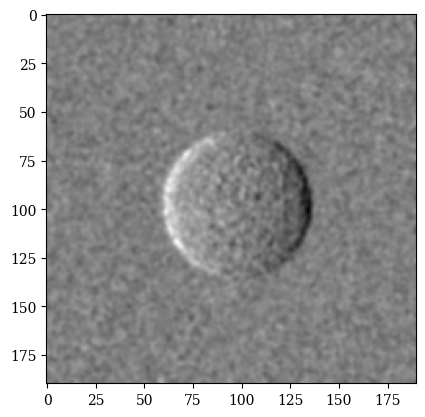

In [58]:
dy_sim = dy_images[0]
dx_sim = dx_images[0]
plt.imshow(dx_sim, cmap='gray', vmin=-1, vmax=1)

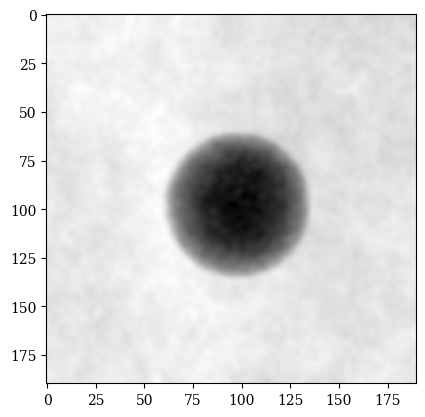

In [59]:
phi_UMPA_sim = -phaseint_fourier(dx_sim, dy_sim)
plt.imshow(phi_UMPA_sim, cmap='gray')


---- ERRORES (RMSE vs Teórico) ----
UMPA: 499.05715043898374
Simulado: 5470.546661796608


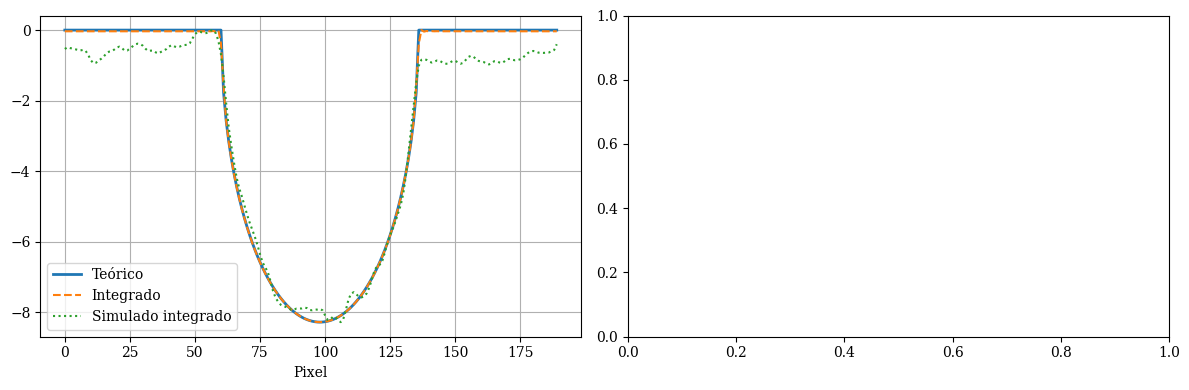

In [60]:


# --- EXTRAER PERFILES ---
h, w = phase_theo.shape

perfil_ref = phase_theo[h//2, :]
perfil = phi_UMPA[h//2, :]
perfil_s = phi_UMPA_sim[h//2, :]

# --- RE-REFERENCIAR (máximo → 0, todo negativo) ---
perfil_ref = perfil_ref - np.max(perfil_ref)
perfil = perfil - np.max(perfil)
perfil_s = perfil_s - np.max(perfil_s)

# --- ASEGURAR MISMO SIGNO ---
if np.min(perfil) > 0:
    perfil = -perfil
if np.min(perfil_s) > 0:
    perfil_s = -perfil_s

# =========================
# 🔵 NORMALIZACIÓN AL TEÓRICO
# =========================
scale = np.min(perfil_ref) / np.min(perfil)
scale_sim = np.min(perfil_ref) / np.min(perfil_s)

perfil_scaled = perfil * scale
perfil_sim_scaled = perfil_s * scale_sim

# =========================
# 🟢 NORMALIZACIÓN AL SIMULADO
# =========================
scale_ref_sim = np.min(perfil_s) / np.min(perfil_ref)
scale_exp_sim = np.min(perfil_s) / np.min(perfil)

perfil_ref_scaled_sim = perfil_ref * scale_ref_sim
perfil_scaled_sim = perfil * scale_exp_sim
perfil_sim_ref = perfil_s  # referencia

# =========================
# 📊 MÉTRICAS
# =========================
amp_ref = np.min(perfil_ref)
amp = np.min(perfil)
amp_sim = np.min(perfil_s)

# Error RMSE respecto al teórico
rmse_exp = np.sqrt(np.mean((perfil_scaled - perfil_ref)**2))
rmse_sim = np.sqrt(np.mean((perfil_sim_scaled - perfil_ref)**2))

print("\n---- ERRORES (RMSE vs Teórico) ----")
print("UMPA:", rmse_exp)
print("Simulado:", rmse_sim)

# =========================
# 📈 GRÁFICAS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12,4))



# --- Panel 2: normalizado al simulado ---
axes[0].plot(perfil_ref_scaled_sim, label="Teórico", linewidth=2)
axes[0].plot(perfil_scaled_sim, label="Integrado", linestyle="--")
axes[0].plot(perfil_sim_ref, label="Simulado integrado", linestyle=":")

axes[0].set_xlabel("Pixel")
axes[0].grid()
axes[0].legend()

plt.tight_layout()
plt.show()

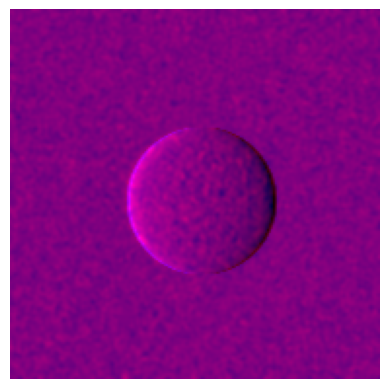

In [61]:
# Normalize both images to [0,1] for RGB
img1 = dx_images[0]
img2 = ground_truth(cx=cx, cy=cy,R=R)[0]#shift(ground_truth(cx=cx, cy=cy,R=R)[0], shift=(3, 1), mode='constant', cval=0.0)

img1 = (img1 - img1.min()) / (img1.max() - img1.min())
img2 = (img2 - img2.min()) / (img2.max() - img2.min())

# Create an RGB image: assign channels
# Example: img1 -> Red, img2 -> Green, no Blue
rgb = np.zeros((img1.shape[0], img1.shape[1], 3))
rgb[..., 0] = img1  # Red channel
rgb[..., 2] = img2  # Blue channel
# rgb[..., 1] left as 0 (Green)

plt.imshow(rgb)
plt.axis("off")
plt.show()

### 1.1 SNR Study

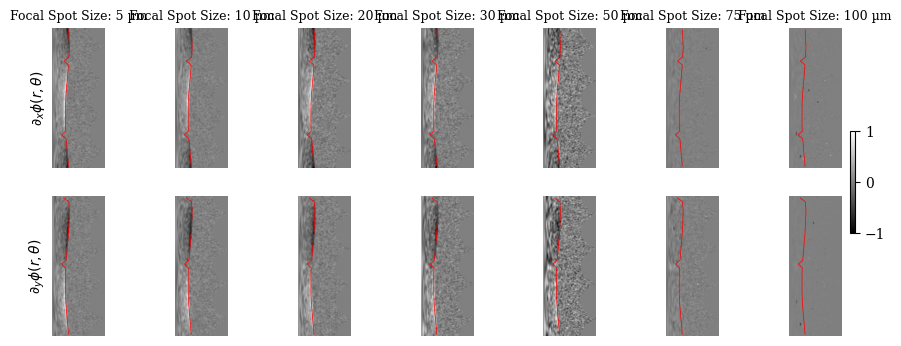

In [62]:
fig, axes = plt.subplots(2, len(focal_spots), figsize=(11, 4))
axes = axes.ravel()

pos_borders_x = []
pos_borders_y = []

for i in range(len(focal_spots)):
    # Top row (dx images)
    ax_dx = axes[i]
    im_dx = ax_dx.imshow(dx_images_polar[i], cmap='gray', vmin=-1, vmax=1)
    ax_dx.plot(binning(ground_truth_contour_x[:, 1], bin_size=10), binning(ground_truth_contour_x[:, 0], bin_size=10), color='red', linewidth=0.5)

    ax_dx.set_title(f"Focal Spot Size: {focal_spots[i]} µm", fontsize=9)
    if i == 0:
        ax_dx.set_ylabel(r'$\partial_x \phi(r,\theta)$', fontsize=10)

    ax_dx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dx.spines.values():
        spine.set_visible(False)
    
    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    #if(i == 0):
    #    ax_dx.add_artist(scalebar)

    # Bottom row (dy images)
    ax_dy = axes[i + len(focal_spots)]
    im_dy = ax_dy.imshow(dy_images_polar[i], cmap='gray', vmin=-1, vmax=1)
    ax_dy.plot(binning(ground_truth_contour_y[:, 1], bin_size=10), binning(ground_truth_contour_y[:, 0], bin_size=10), color='red', linewidth=0.5)

    if i == 0:
        ax_dy.set_ylabel(r'$\partial_y \phi(r,\theta)$', fontsize=10)

    ax_dy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dy.spines.values():
        spine.set_visible(False)

    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    #if(i == 0):
    #    ax_dy.add_artist(scalebar)

# Single shared colorbar
cbar = fig.colorbar(im_dx, ax=axes, orientation="vertical", fraction=0.006, pad=0.01)
#cbar.set_label("Normalized diff. phase [a.u.]")

In [70]:
SNR_x_FS_new = []
std_SNR_x_FS_new = []
SNR_y_FS_new = []
std_SNR_y_FS_new = []

for i in range(len(focal_spots)):
    if(i <= 3):
        snr_x, std_snr_x = bootstrap_SNR(dx_images[i], dx_images_polar[i], img_border=ground_truth_x, img_polar_border=polar_ground_truth_x)
        snr_y, std_snr_y = bootstrap_SNR(dy_images[i], dy_images_polar[i], img_border=ground_truth_y, img_polar_border=polar_ground_truth_y)
    else:
        snr_x, std_snr_x = bootstrap_SNR(dx_images[i], dx_images_polar[i], img_border=ground_truth_x, img_polar_border=polar_ground_truth_x, outlier_removal=True)
        snr_y, std_snr_y = bootstrap_SNR(dy_images[i], dy_images_polar[i], img_border=ground_truth_y, img_polar_border=polar_ground_truth_y, outlier_removal=True)
    SNR_x_FS_new.append(snr_x)
    std_SNR_x_FS_new.append(std_snr_x)
    SNR_y_FS_new.append(snr_y)
    std_SNR_y_FS_new.append(std_snr_y)



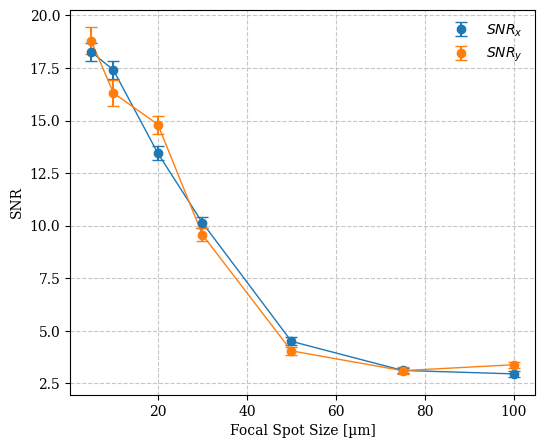

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(6,5))

# --- SNR_x ---
plt.errorbar(
    focal_spots,
    SNR_x_FS_new,
    yerr=std_SNR_x_FS_new,
    fmt='o',
    capsize=4,
    color='C0',
    label=r'$SNR_x$'
)

# Línea conectando puntos
plt.plot(focal_spots, SNR_x_FS_new,
         '-', lw=1, color='C0')

# --- SNR_y ---
plt.errorbar(
    focal_spots,
    SNR_y_FS_new,
    yerr=std_SNR_y_FS_new,
    fmt='o',
    capsize=4,
    color='C1',
    label=r'$SNR_y$'
)

# Línea conectando puntos
plt.plot(focal_spots, SNR_y_FS_new,
         '-', lw=1, color='C1')

plt.xlabel("Focal Spot Size [µm]")
plt.ylabel("SNR")

plt.grid(linestyle='--', alpha=0.7)
plt.legend(frameon=False)

os.makedirs("ARTICLE_RESULTS", exist_ok=True)

plt.savefig("ARTICLE_RESULTS/SNR_vs_FocalSpotSize.png",
            dpi=300,
            bbox_inches="tight")

plt.savefig("ARTICLE_RESULTS/SNR_vs_FocalSpotSize.pdf",
            bbox_inches="tight")

plt.show()

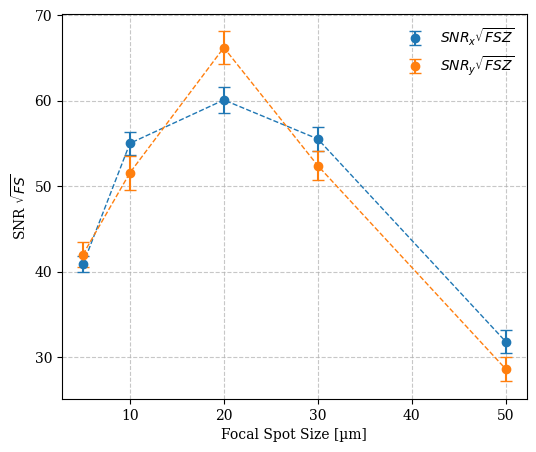

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Convertir a arrays
focal_spots_arr = np.array(focal_spots)

SNR_x_FS_new = np.array(SNR_x_FS_new)
SNR_y_FS_new = np.array(SNR_y_FS_new)
std_SNR_x_FS_new = np.array(std_SNR_x_FS_new)
std_SNR_y_FS_new = np.array(std_SNR_y_FS_new)

# Escalar
SNR_x_scaled = SNR_x_FS_new * np.sqrt(focal_spots_arr)
SNR_y_scaled = SNR_y_FS_new * np.sqrt(focal_spots_arr)

std_SNR_x_scaled = std_SNR_x_FS_new * np.sqrt(focal_spots_arr)
std_SNR_y_scaled = std_SNR_y_FS_new * np.sqrt(focal_spots_arr)

# Remover 100 y 300
mask = (focal_spots_arr != 100) & (focal_spots_arr != 75)

focal_spots_filtered = focal_spots_arr[mask]

SNR_x_scaled_filtered = SNR_x_scaled[mask]
SNR_y_scaled_filtered = SNR_y_scaled[mask]

std_SNR_x_scaled_filtered = std_SNR_x_scaled[mask]
std_SNR_y_scaled_filtered = std_SNR_y_scaled[mask]

# --- Plot estilo artículo ---
plt.figure(figsize=(6,5))

# SNR_x √FS
plt.errorbar(
    focal_spots_filtered,
    SNR_x_scaled_filtered,
    yerr=std_SNR_x_scaled_filtered,
    fmt='o',
    capsize=4,
    color='C0',
    label=r'$SNR_x \sqrt{FSZ}$'
)

plt.plot(
    focal_spots_filtered,
    SNR_x_scaled_filtered,
    '--', lw=1, color='C0'
)

# SNR_y √FS
plt.errorbar(
    focal_spots_filtered,
    SNR_y_scaled_filtered,
    yerr=std_SNR_y_scaled_filtered,
    fmt='o',
    capsize=4,
    color='C1',
    label=r'$SNR_y \sqrt{FSZ}$'
)

plt.plot(
    focal_spots_filtered,
    SNR_y_scaled_filtered,
    '--', lw=1, color='C1'
)

plt.xlabel("Focal Spot Size [µm]")
plt.ylabel(r"SNR $\sqrt{FS}$")

plt.grid(linestyle='--', alpha=0.7)
plt.legend(frameon=False)

os.makedirs("ARTICLE_RESULTS", exist_ok=True)

plt.savefig("ARTICLE_RESULTS/SNRsqrtFS_vs_FocalSpotSize.png",
            dpi=300,
            bbox_inches="tight")

plt.savefig("ARTICLE_RESULTS/SNRsqrtFS_vs_FocalSpotSize.pdf",
            bbox_inches="tight")

plt.show()

In [73]:
print(SNR_x_scaled_filtered ,
SNR_y_scaled_filtered)

[40.85385752 55.03064816 60.1049278  55.54211084 31.83079954] [42.02025347 51.58509677 66.23430992 52.41798167 28.62657315]


### 1.2 NRMSE Study

Text(0, 0.5, 'NRMSE')

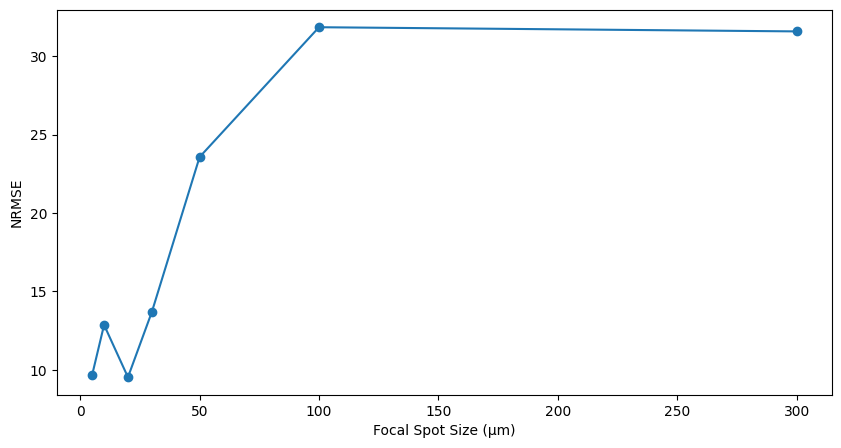

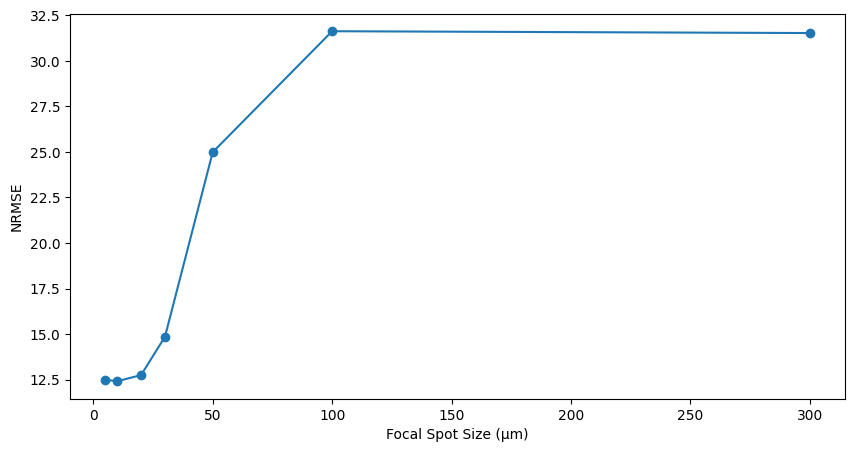

In [80]:
NRMSE_dxs = []
NRMSE_dys = []
std_NRMSE_dxs = []
std_NRMSE_dys = []
for i in range(len(focal_spots)):
    if(i <= 3):
        outlier_removal = False
    else:
        outlier_removal = False

    GT_profile_x, GT_profile_y = polar_ground_truth_x[ground_truth_contour_x[:,0], ground_truth_contour_x[:,1]], polar_ground_truth_y[ground_truth_contour_y[:,0], ground_truth_contour_y[:,1]]

    contour_x, contour_y = ground_truth_contour_x, ground_truth_contour_y #detect_border(dx_images_polar[i]), detect_border(dy_images_polar[i])
    profile_i_x, profile_i_y = dx_images_polar[i][contour_x[:,0], contour_x[:,1]], dy_images_polar[i][contour_x[:,0], contour_x[:,1]]

    
    NRMSE_dxs.append(bootstrap_NRMSE(profile_ref=GT_profile_x, profile_test=profile_i_x, outlier_removal=outlier_removal)[0])

    NRMSE_dys.append(bootstrap_NRMSE(profile_ref=GT_profile_y, profile_test=profile_i_y, outlier_removal=outlier_removal)[0])

    std_NRMSE_dxs.append(bootstrap_NRMSE(profile_ref=GT_profile_x, profile_test=profile_i_x, outlier_removal=outlier_removal)[1])

    std_NRMSE_dys.append(bootstrap_NRMSE(profile_ref=GT_profile_y, profile_test=profile_i_y, outlier_removal=outlier_removal)[1])

NRMSE_dxs_FS = np.array(NRMSE_dxs)
NRMSE_dys_FS = np.array(NRMSE_dys)
std_NRMSE_dxs_FS = np.array(std_NRMSE_dxs)
std_NRMSE_dys_FS = np.array(std_NRMSE_dys)

plt.figure(figsize=(10, 5))
plt.plot(focal_spots, NRMSE_dxs)
plt.scatter(focal_spots, NRMSE_dxs)
plt.xlabel("Focal Spot Size (µm)")
plt.ylabel("NRMSE")

plt.figure(figsize=(10, 5))
plt.plot(focal_spots, NRMSE_dys)
plt.scatter(focal_spots, NRMSE_dys)
plt.xlabel("Focal Spot Size (µm)")
plt.ylabel("NRMSE")

### 1.3 Visibility Study 

In [633]:
#folder_names = ["2.5um", "15um", "50um", "100um", "300um"]
#focal_spots = [2.5, 15, 50, 100, 300]  # in micrometers
input_folder = "/Users/manuelfernandosanchezalarcon/Desktop/Images_CTibambre_Article/FSZ_Study/"
ref_images = []

for i, folder in enumerate(folder_names):
    ref_name = f"{folder}/Nylon_Air_TiC_2mm_2x_150_75_21kev_R00_FS{folder}_Random__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw"
    data_infile = open(input_folder + ref_name,'rb')
    data_array = np.fromfile(data_infile,dtype='float32',count=256*256)
    data_image = PIL.Image.frombuffer("F",[256,256],data_array,'raw','F',0,1)
    img = np.array(data_image.getdata())
    img =img.reshape(256,256) 
    img = img[13:-13, 13:-13]
    ref_images.append(img)

mean_vis_FS = []
std_vis_FS = [] 

for ref_image in ref_images:
    # Reshape into patches
    patches = np.array_split(ref_image,num_patches)
    visibilities = []

    for patch in patches:
        visibility = Visibility(patch)
        visibilities.append(visibility)

    visibilities = np.array(visibilities)
    mean_vis_FS.append(np.mean(visibilities))
    std_vis_FS.append(np.std(visibilities))

mean_vis_FS = np.array(mean_vis_FS)
std_vis_FS = np.array(std_vis_FS)


Text(0, 0.5, 'Visibility (%)')

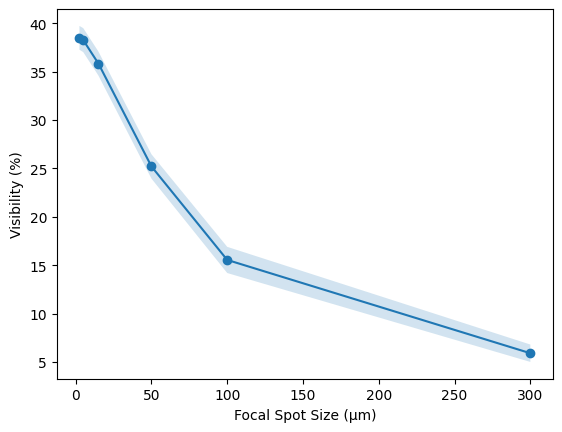

In [634]:
plt.plot(focal_spots, mean_vis_FS, "-o")
plt.fill_between(focal_spots, mean_vis_FS - std_vis_FS, mean_vis_FS + std_vis_FS, alpha=0.2)
plt.xlabel("Focal Spot Size (µm)")
plt.ylabel("Visibility (%)")

## 2. Grain Material Study

In [635]:
folder_names = ["SiC", "2.5um"]
folder_titles = ["Grain Material: SiC", "Grain Material: TiC"]
input_folder = "/Users/manuelfernandosanchezalarcon/Desktop/Images_CTibambre_Article/FSZ_Study/"
dx_name = "dx.txt"
dy_name = "dy.txt"
dx_images = []
dy_images = []
dx_images_polar = []
dy_images_polar = []

for folder in folder_names:
    dx = np.loadtxt(input_folder + folder + "/" + dx_name)
    dy = np.loadtxt(input_folder + folder + "/" + dy_name)
    dx = dx / np.max(np.abs(dx))  # Normalize to max value
    dy = dy / np.max(np.abs(dy))  # Normalize to max value
    dx_images_polar.append(to_polar(dx))
    dy_images_polar.append(to_polar(dy))
    dx_images.append(dx)
    dy_images.append(dy)

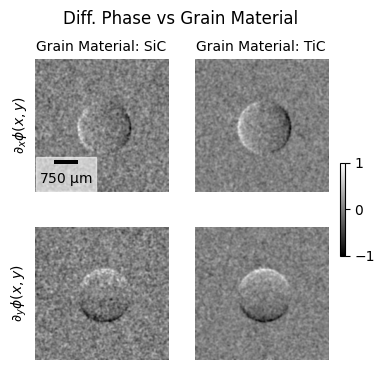

In [636]:
fig, axes = plt.subplots(2, len(folder_names), figsize=(4, 4))
axes = axes.ravel()

for i in range(len(folder_names)):
    # Top row (dx images)
    ax_dx = axes[i]
    im_dx = ax_dx.imshow(dx_images[i], cmap='gray', vmin=-1, vmax=1)
    ax_dx.set_title(folder_titles[i], fontsize=10)
    if i == 0:
        ax_dx.set_ylabel(r'$\partial_x \phi(x,y)$', fontsize=10)

    ax_dx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dx.spines.values():
        spine.set_visible(False)
    
    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    if(i == 0):
        ax_dx.add_artist(scalebar)

    # Bottom row (dy images)
    ax_dy = axes[i + len(folder_names)]
    im_dy = ax_dy.imshow(dy_images[i], cmap='gray', vmin=-1, vmax=1)
    if i == 0:
        ax_dy.set_ylabel(r'$\partial_y \phi(x,y)$', fontsize=10)

    ax_dy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dy.spines.values():
        spine.set_visible(False)

    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    #if(i == 0):
    #    ax_dy.add_artist(scalebar)

# Single shared colorbar
cbar = fig.colorbar(im_dx, ax=axes, orientation="vertical", fraction=0.015, pad=0.04)
#cbar.set_label("Normalized diff. phase [a.u.]")
plt.text(-20, -310, "Diff. Phase vs Grain Material", ha="center", va="top", fontsize=12)
plt.savefig("DiffPhase_vs_GrainMaterial.pdf", dpi=300, bbox_inches='tight')

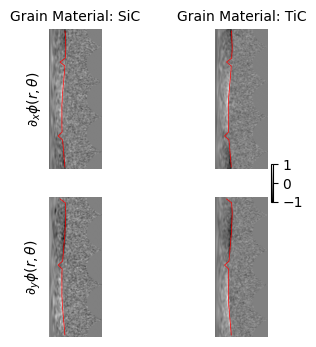

In [637]:
fig, axes = plt.subplots(2, len(folder_names), figsize=(4, 4))
axes = axes.ravel()

pos_borders_x = []
pos_borders_y = []

for i in range(len(folder_names)):
    # Top row (dx images)
    ax_dx = axes[i]
    im_dx = ax_dx.imshow(dx_images_polar[i], cmap='gray', vmin=-1, vmax=1)
    ax_dx.plot(binning(ground_truth_contour_x[:, 1], bin_size=10), binning(ground_truth_contour_x[:, 0], bin_size=10), color='red', linewidth=0.5)

    ax_dx.set_title(folder_titles[i], fontsize=10)
    if i == 0:
        ax_dx.set_ylabel(r'$\partial_x \phi(r,\theta)$', fontsize=10)

    ax_dx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dx.spines.values():
        spine.set_visible(False)
    
    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    #if(i == 0):
    #    ax_dx.add_artist(scalebar)

    # Bottom row (dy images)
    ax_dy = axes[i + len(folder_names)]
    im_dy = ax_dy.imshow(dy_images_polar[i], cmap='gray', vmin=-1, vmax=1)
    pos_border_y = []
    ax_dy.plot(binning(ground_truth_contour_y[:, 1], bin_size=10), binning(ground_truth_contour_y[:, 0], bin_size=10), color='red', linewidth=0.5)

    if i == 0:
        ax_dy.set_ylabel(r'$\partial_y \phi(r,\theta)$', fontsize=10)

    ax_dy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax_dy.spines.values():
        spine.set_visible(False)

    scalebar = ScaleBar(22.5, "um", color="black",
                            location="lower left", box_alpha=0.6,
                            scale_loc="bottom", width_fraction=0.03)
    #if(i == 0):
    #    ax_dy.add_artist(scalebar)

# Single shared colorbar
cbar = fig.colorbar(im_dx, ax=axes, orientation="vertical", fraction=0.006, pad=0.01)
#cbar.set_label("Normalized diff. phase [a.u.]")

Text(0, 0.5, 'SNR')

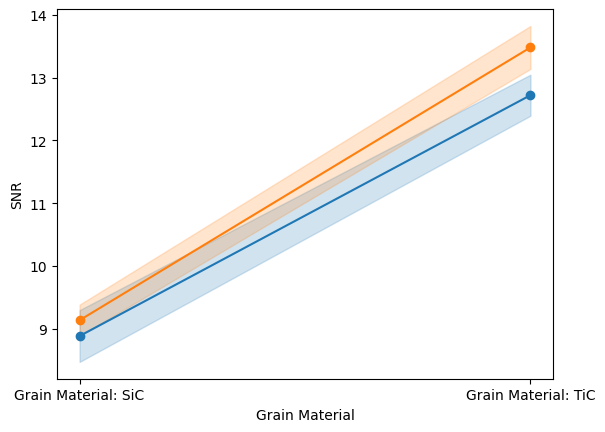

In [638]:
SNR_x_GM_new = []
std_SNR_x_GM_new = []
SNR_y_GM_new = []
std_SNR_y_GM_new = []

for i in range(len(folder_names)):
    snr_x, std_snr_x = bootstrap_SNR(dx_images[i], dx_images_polar[i], img_border=ground_truth_x, img_polar_border=polar_ground_truth_x)
    snr_y, std_snr_y = bootstrap_SNR(dy_images[i], dy_images_polar[i], img_border=ground_truth_y, img_polar_border=polar_ground_truth_y)
    SNR_x_GM_new.append(snr_x)
    std_SNR_x_GM_new.append(std_snr_x)
    SNR_y_GM_new.append(snr_y)
    std_SNR_y_GM_new.append(std_snr_y)

plt.plot(folder_titles, SNR_x_GM_new, marker='o', label='SNR_x (bootstrap)', color='C0')
plt.fill_between(folder_titles, np.array(SNR_x_GM_new)-np.array(std_SNR_x_GM_new), np.array(SNR_x_GM_new)+np.array(std_SNR_x_GM_new), color='C0', alpha=0.2)
plt.plot(folder_titles, SNR_y_GM_new, marker='o', label='SNR_y (bootstrap)', color='C1')
plt.fill_between(folder_titles, np.array(SNR_y_GM_new)-np.array(std_SNR_y_GM_new), np.array(SNR_y_GM_new)+np.array(std_SNR_y_GM_new), color='C1', alpha=0.2)
plt.xlabel("Grain Material")
plt.ylabel("SNR")

### 2.2 NRMSE Study

/var/folders/2d/x796vcwx3qz_3vh3b3bt66g80000gn/T/ipykernel_47556/3932814956.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


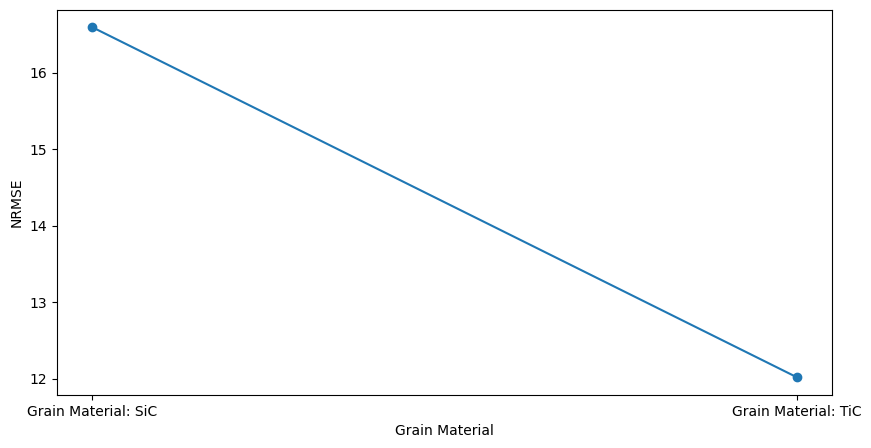

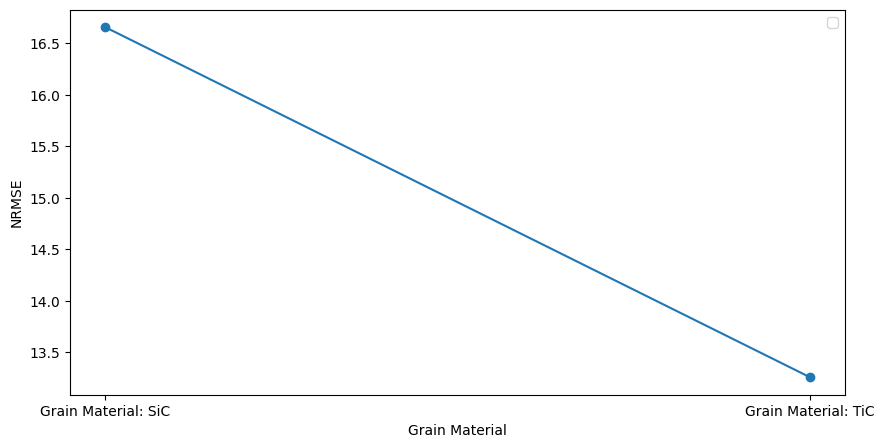

In [639]:
NRMSE_dxs = []
NRMSE_dys = []
std_NRMSE_dxs = []
std_NRMSE_dys = []
for i in range(len(folder_names)):
    #row_NRMSEn = np.where(dx_images_polar[0] == np.max(dx_images_polar[0]))[0][0]

    outlier_removal = False

    GT_profile_x, GT_profile_y = polar_ground_truth_x[ground_truth_contour_x[:,0], ground_truth_contour_x[:,1]], polar_ground_truth_y[ground_truth_contour_y[:,0], ground_truth_contour_y[:,1]]

    contour_x, contour_y = ground_truth_contour_x, ground_truth_contour_y #detect_border(dx_images_polar[i]), detect_border(dy_images_polar[i])
    profile_i_x, profile_i_y = dx_images_polar[i][contour_x[:,0], contour_x[:,1]], dy_images_polar[i][contour_x[:,0], contour_x[:,1]]

    NRMSE_dxs.append(bootstrap_NRMSE(profile_ref=GT_profile_x, profile_test=profile_i_x, outlier_removal=outlier_removal)[0])
    NRMSE_dys.append(bootstrap_NRMSE(profile_ref=GT_profile_y, profile_test=profile_i_y, outlier_removal=outlier_removal)[0])
    std_NRMSE_dxs.append(bootstrap_NRMSE(profile_ref=GT_profile_x, profile_test=profile_i_x, outlier_removal=outlier_removal)[1])
    std_NRMSE_dys.append(bootstrap_NRMSE(profile_ref=GT_profile_y, profile_test=profile_i_y, outlier_removal=outlier_removal)[1])

NRMSE_dxs_GM = np.array(NRMSE_dxs)
NRMSE_dys_GM = np.array(NRMSE_dys)
std_NRMSE_dxs_GM = np.array(std_NRMSE_dxs)
std_NRMSE_dys_GM = np.array(std_NRMSE_dys)

plt.figure(figsize=(10, 5))
plt.plot(folder_titles, NRMSE_dxs)
plt.scatter(folder_titles, NRMSE_dxs)
plt.xlabel("Grain Material")
plt.ylabel("NRMSE")

plt.figure(figsize=(10, 5))
plt.plot(folder_titles, NRMSE_dys)
plt.scatter(folder_titles, NRMSE_dys)
plt.xlabel("Grain Material")
plt.ylabel("NRMSE")
plt.legend()

### 2.4 Visibility Study

In [640]:
input_folder = "/Users/manuelfernandosanchezalarcon/Desktop/Images_CTibambre_Article/FSZ_Study/"
ref_names = ["SiC/FS_Measurements/Nylon_Air_2mm_2x_150_75_21kev_R00_FS10um__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw",
             "2.5um/Nylon_Air_TiC_2mm_2x_150_75_21kev_R00_FS2.5um_Random__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw"]
ref_images = []

for i, folder in enumerate(folder_names):
    ref_name = ref_names[i]
    data_infile = open(input_folder + ref_name,'rb')
    data_array = np.fromfile(data_infile,dtype='float32',count=256*256)
    data_image = PIL.Image.frombuffer("F",[256,256],data_array,'raw','F',0,1)
    img = np.array(data_image.getdata())
    img =img.reshape(256,256) 
    img = img[13:-13, 13:-13]
    ref_images.append(img)

mean_vis_GM = []
std_vis_GM = [] 

for ref_image in ref_images:
    # Reshape into patches
    patches = np.array_split(ref_image,num_patches)
    visibilities = []

    for patch in patches:
        visibility = Visibility(patch)
        visibilities.append(visibility)

    visibilities = np.array(visibilities)
    mean_vis_GM.append(np.mean(visibilities))
    std_vis_GM.append(np.std(visibilities))

mean_vis_GM = np.array(mean_vis_GM)
std_vis_GM = np.array(std_vis_GM)

Text(0, 0.5, 'Visibility (%)')

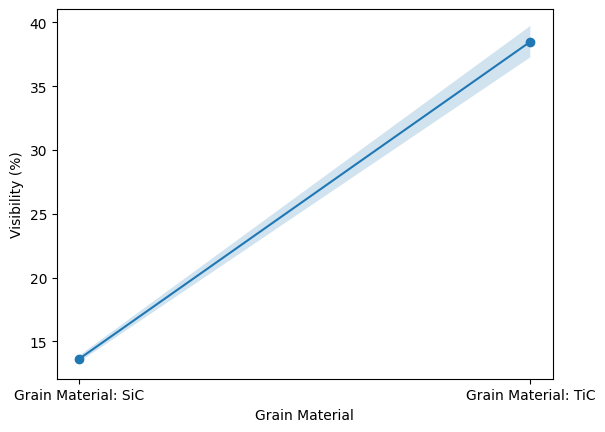

In [641]:
plt.plot(folder_titles, mean_vis_GM, "-o")
plt.fill_between(folder_titles, mean_vis_GM - std_vis_GM, mean_vis_GM + std_vis_GM, alpha=0.2)
plt.xlabel("Grain Material")
plt.ylabel("Visibility (%)")

## 3. Joined Results

### 3.1 SNR

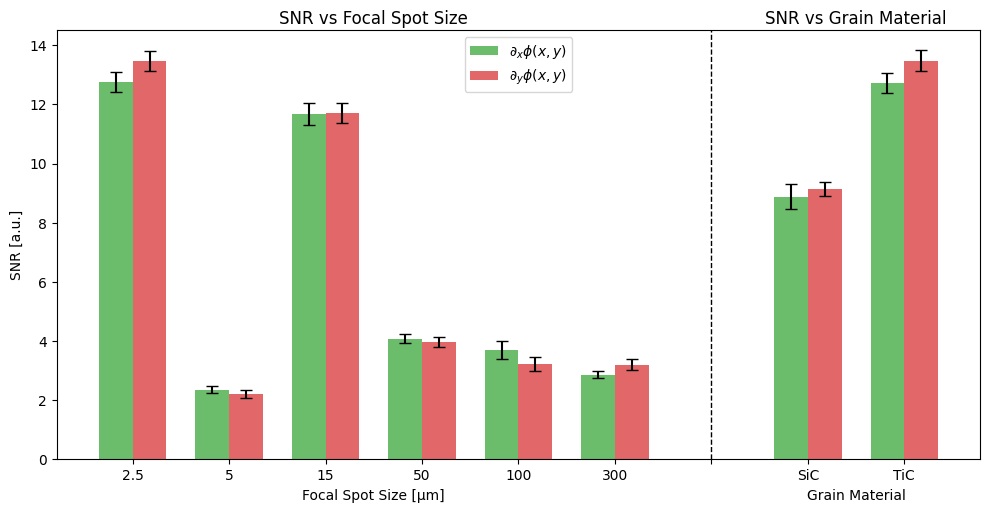

In [642]:
focal_spots = ["2.5", "5" ,"15", "50", "100", "300"]
snr_x = list(SNR_x_FS_new)#list(SNR_x_FS_new[:3])
snr_y = list(SNR_y_FS_new)#list(SNR_y_FS_new[:3])
std_snr_x = list(std_SNR_x_FS_new)#list(std_SNR_x_FS_new[:3])
std_snr_y = list(std_SNR_y_FS_new)#list(std_SNR_y_FS_new[:3])

materials = ["SiC", "TiC"]
snr_x2 = list(SNR_x_GM_new)
snr_y2 = list(SNR_y_GM_new)
std_snr_x2 = list(std_SNR_x_GM_new)
std_snr_y2 = list(std_SNR_y_GM_new)

# Build combined categories with a separator
categories = focal_spots + [""] + materials   # "" makes a visual gap
snr_x_all = snr_x + [np.nan] + snr_x2         # nan -> no bar in the gap
snr_y_all = snr_y + [np.nan] + snr_y2
std_snr_x_all = std_snr_x + [np.nan] + std_snr_x2 
std_snr_y_all = std_snr_y + [np.nan] + std_snr_y2

x = np.arange(len(categories))
width = 0.35


# Choose a colormap and sample distinct colors for each dataset
colors = ["#2ca02c", "#d62728"]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, snr_x_all, width, yerr=std_snr_x_all, capsize=4 ,label=r'$\partial_x \phi(x,y)$', color=colors[0], alpha=0.7)
plt.bar(x + width/2, snr_y_all, width, yerr=std_snr_y_all, capsize=4 ,label=r'$\partial_y \phi(x,y)$', color=colors[1], alpha=0.7)
plt.axvline(x=len(focal_spots), color='black', linestyle='--', linewidth=1)  # Separator line

plt.xticks(x, categories, rotation=0)

# Add group labels
plt.text(len(focal_spots)/2 - 0.5, -1, "Focal Spot Size [µm]", ha="center", va="top", fontsize=10)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, -1, "Grain Material", ha="center", va="top", fontsize=10)

plt.ylabel("SNR [a.u.]")
plt.legend()
plt.tight_layout()
plt.text(len(focal_spots)/2 - 0.5, 15.2, "SNR vs Focal Spot Size", ha="center", va="top", fontsize=12)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, 15.2, "SNR vs Grain Material", ha="center", va="top", fontsize=12)

plt.savefig("SNR_results.pdf", dpi=300, bbox_inches='tight')

### 3.2 NRMSE Information

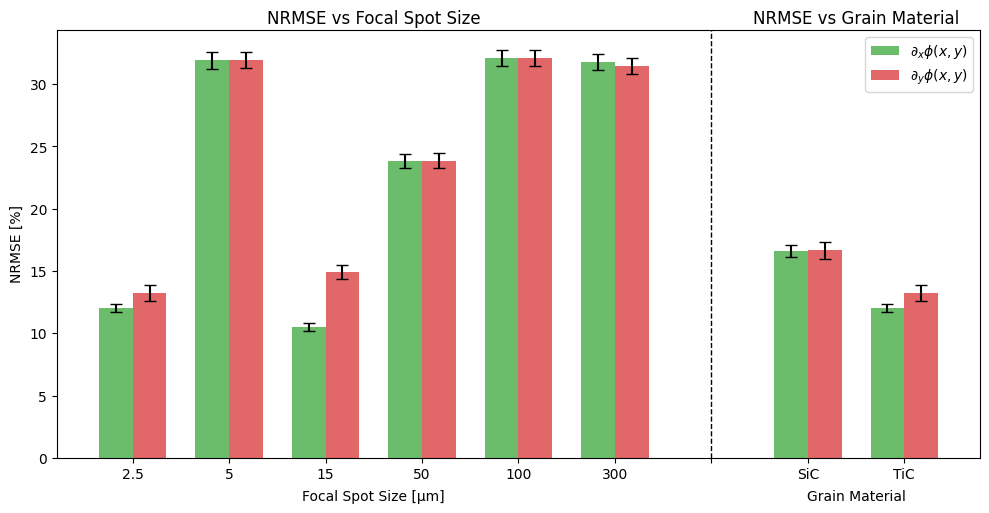

In [647]:
focal_spots = ["2.5", "5" ,"15", "50", "100", "300"]
NRMSE_dxs = list(NRMSE_dxs_FS[:])#list(NRMSE_dxs_FS[:3])
NRMSE_dys = list(NRMSE_dys_FS[:])#list(NRMSE_dys_FS[:3])
std_NRMSE_dxs = list(std_NRMSE_dxs_FS[:])#list(std_NRMSE_dxs_FS[:3])
std_NRMSE_dys = list(std_NRMSE_dys_FS[:])#list(std_NRMSE_dys_FS[:3])

materials = ["SiC", "TiC"]
NRMSE_dxs2 = list(NRMSE_dxs_GM)
NRMSE_dys2 = list(NRMSE_dys_GM)
std_NRMSE_dxs2 = list(std_NRMSE_dxs_GM)
std_NRMSE_dys2 = list(std_NRMSE_dys_GM)

# Build combined categories with a separator
categories = focal_spots + [""] + materials   # "" makes a visual gap
NRMSE_dxs_all = NRMSE_dxs + [np.nan] + NRMSE_dxs2         # nan -> no bar in the gap
NRMSE_dys_all = NRMSE_dys + [np.nan] + NRMSE_dys2
std_NRMSE_dxs_all = std_NRMSE_dxs + [np.nan] + std_NRMSE_dxs2 
std_NRMSE_dys_all = std_NRMSE_dys + [np.nan] + std_NRMSE_dys2

x = np.arange(len(categories))
width = 0.35


# Choose a colormap and sample distinct colors for each dataset
colors = ["#2ca02c", "#d62728"]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, NRMSE_dxs_all, width, yerr=std_NRMSE_dxs_all, capsize=4 ,label=r'$\partial_x \phi(x,y)$', color=colors[0], alpha=0.7)
plt.bar(x + width/2, NRMSE_dys_all, width, yerr=std_NRMSE_dys_all, capsize=4 ,label=r'$\partial_y \phi(x,y)$', color=colors[1], alpha=0.7)
plt.axvline(x=len(focal_spots), color='black', linestyle='--', linewidth=1)  # Separator line

plt.xticks(x, categories, rotation=0)

# Add group labels
plt.text(len(focal_spots)/2 - 0.5, -2.5, "Focal Spot Size [µm]", ha="center", va="top", fontsize=10)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, -2.5, "Grain Material", ha="center", va="top", fontsize=10)

plt.ylabel("NRMSE [%]")
plt.legend()
plt.tight_layout()
plt.text(len(focal_spots)/2 - 0.5, 36, "NRMSE vs Focal Spot Size", ha="center", va="top", fontsize=12)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, 36, "NRMSE vs Grain Material", ha="center", va="top", fontsize=12)

plt.savefig("NRMSE_results.pdf", dpi=300, bbox_inches='tight')



### 3.3 Visibility

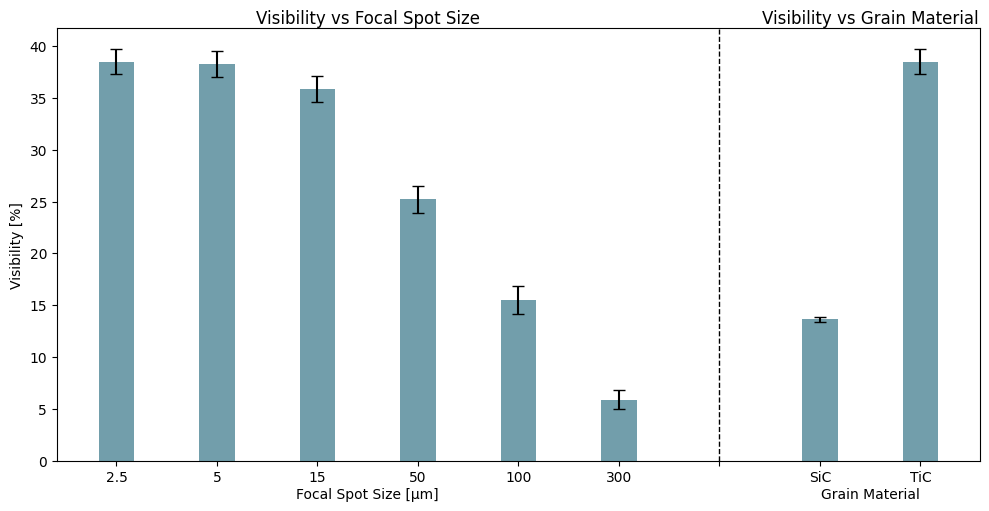

In [644]:
# Choose a colormap and sample distinct colors for each dataset
cmap = plt.get_cmap("Paired")   # try "Set2", 'tab10', 'Pastel1', 'Dark2', etc.
colors = ["#367588"]

# --- Focal spots como números ---
focal_spots = ["2.5", "5" ,"15", "50", "100", "300"]
vis = list(mean_vis_FS)
std_vis = list(std_vis_FS)

# --- Grain materials (categorías) ---
materials = ["SiC", "TiC"]
vis_2 = list(mean_vis_GM)
std_vis_2 = list(std_vis_GM)

# Build combined categories with a separator
categories = focal_spots + [""] + materials   # "" makes a visual gap
vis_all = vis + [np.nan] + vis_2         # nan -> no bar in the gap
std_vis_all = std_vis + [np.nan] + std_vis_2

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x, vis_all, width, yerr=std_vis_all, capsize=4, color=colors[0], alpha=0.7)
plt.axvline(x=len(focal_spots), color='black', linestyle='--', linewidth=1)  # Separator line

plt.xticks(x, categories, rotation=0)

# Add group labels
plt.text(len(focal_spots)/2 - 0.5, -2.5, "Focal Spot Size [µm]", ha="center", va="top", fontsize=10)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, -2.5, "Grain Material", ha="center", va="top", fontsize=10)

plt.ylabel("Visibility [%]")
plt.tight_layout()
plt.text(len(focal_spots)/2 - 0.5, 43.5, "Visibility vs Focal Spot Size", ha="center", va="top", fontsize=12)
plt.text(len(focal_spots) + 1 + len(materials)/2 - 0.5, 43.5, "Visibility vs Grain Material", ha="center", va="top", fontsize=12)

plt.savefig("Visibility_results.pdf", dpi=300, bbox_inches='tight')